In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [6]:
df_new = pd.read_csv("../data/merged_clean.csv")

In [7]:
pd.crosstab(df_new["covid_misinfo_belief"], df_new["trump_vote"], normalize="index")

df_new.groupby("covid_misinfo_belief")["trump_vote"].mean()

covid_misinfo_belief
0.0    0.261222
1.0    0.654049
Name: trump_vote, dtype: float64

In [8]:
df_new.groupby(["F_PARTYSUM_FINAL", "covid_misinfo_belief"])["trump_vote"].mean()

pd.crosstab(df_new["F_PARTYSUM_FINAL"], df_new["covid_misinfo_belief"], values=df_new["trump_vote"], aggfunc="mean")

covid_misinfo_belief,0.0,1.0
F_PARTYSUM_FINAL,,
DK/Refused/No lean,0.147059,0.409091
Dem/Lean Dem,0.015223,0.065574
Rep/Lean Rep,0.854783,0.949198


In [9]:
pd.crosstab(df_new["F_PARTYSUM_FINAL"], df_new["covid_misinfo_belief"])

covid_misinfo_belief,0.0,1.0
F_PARTYSUM_FINAL,,
DK/Refused/No lean,65,42
Dem/Lean Dem,2942,495
Rep/Lean Rep,1351,869


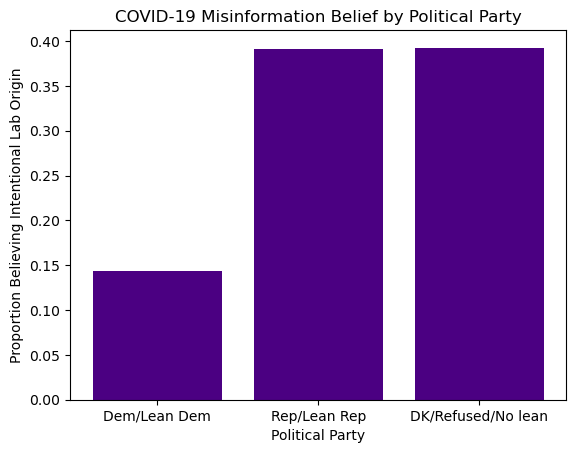

In [10]:
misinfo_by_party = (df_new.groupby("F_PARTYSUM_FINAL")["covid_misinfo_belief"].mean().sort_values())

plt.bar(misinfo_by_party.index, misinfo_by_party.values, color="indigo")
plt.xlabel("Political Party")
plt.ylabel("Proportion Believing Intentional Lab Origin")
plt.title("COVID-19 Misinformation Belief by Political Party")
plt.xticks(rotation=0)

plt.savefig("../output/misinfo_by_party.png",bbox_inches="tight")
plt.show()

In [11]:
vote_by_misinfo = (df_new.groupby("covid_misinfo_belief")["trump_vote"].mean())
vote_by_misinfo

covid_misinfo_belief
0.0    0.261222
1.0    0.654049
Name: trump_vote, dtype: float64

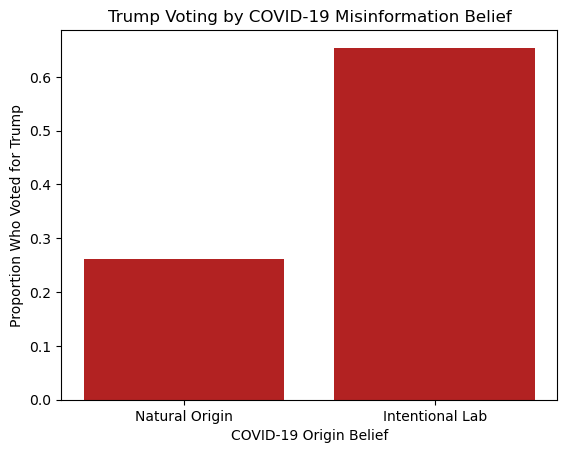

In [18]:
plt.bar(vote_by_misinfo.index, vote_by_misinfo.values, color="firebrick")
plt.xlabel("COVID-19 Origin Belief")
plt.ylabel("Proportion Who Voted for Trump")
plt.title("Trump Voting by COVID-19 Misinformation Belief")
plt.xticks([0, 1], ["Natural Origin", "Intentional Lab"], rotation=0)

plt.savefig("../output/trump_vote_by_misinfo.png", bbox_inches="tight")
plt.show()

In [15]:
party_vote = (df_new.groupby(["F_PARTYSUM_FINAL", "covid_misinfo_belief"])["trump_vote"].mean().unstack())
party_vote

covid_misinfo_belief,0.0,1.0
F_PARTYSUM_FINAL,,
DK/Refused/No lean,0.147059,0.409091
Dem/Lean Dem,0.015223,0.065574
Rep/Lean Rep,0.854783,0.949198


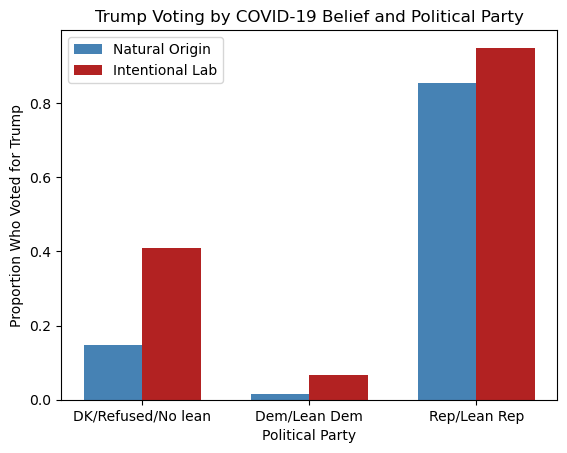

In [19]:
x = np.arange(len(party_vote.index))
width = 0.35

plt.bar(x - width/2, party_vote[0.0], width, label="Natural Origin", color="steelblue")
plt.bar(x + width/2, party_vote[1.0], width, label="Intentional Lab", color="firebrick")

plt.xticks(x, party_vote.index)
plt.xlabel("Political Party")
plt.ylabel("Proportion Who Voted for Trump")
plt.title("Trump Voting by COVID-19 Belief and Political Party")
plt.legend()

plt.savefig("../output/trump_vote_by_misinfo_party.png", bbox_inches="tight")
plt.show()